In [1]:
#importação das bibliotecas necessárias para a análise dos dados
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


In [2]:
# configurações para exibição de dados, no caso, para exibir todas as colunas e formatar
# os números decimais com duas casas. no caso, os dados da sisgram possuem poucas colunas,
# mas prefiro configurar, para o caso de ter outro dataframe maior.

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df_sismigra_jan = pd.read_csv(
    '../dataset/SISMIGRA_REGISTROS_ATIVOS_2026_01.csv', sep=';', encoding='UTF-8'
)
display(df_sismigra_jan)#visualizar o dataframe referente ao mês de janeiro

df_sismigra_fev = pd.read_csv(
    '../dataset/SISMIGRA_REGISTROS_ATIVOS_2026_02.csv', sep=';', encoding='UTF-8'
)
display(df_sismigra_fev)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD
0,SP,BOLÍVIA,Residente,106567
1,SP,INDIA,Residente,1445
2,SP,ANGOLA,Temporário,8219
3,SP,CHILE,Residente,15612
4,SP,JAPÃO,Residente,36258
...,...,...,...,...
6298,AC,GANA,Residente,1
6299,AC,BANGLADESH,Provisório,1
6300,PB,IRAQUE,Residente,1
6301,PB,AFRICA DO SUL,Residente,1


,UF,NACIONALIDADE,CLASSIFICACAO,QTD
0,SP,PORTUGAL,Residente,65585
1,SP,REINO UNIDO,Residente,3775
2,SP,ARGENTINA,Residente,24168
3,SP,BOLÍVIA,Temporário,36665
4,SP,PERU,Residente,16130
...,...,...,...,...
6314,AC,GANA,Temporário,1
6315,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1
6316,PB,IRAQUE,Residente,1
6317,PB,AFRICA DO SUL,Residente,1


In [4]:
df_sismigra_jan.info()#visualizar as informações do dataframe de janeiro
df_sismigra_fev.info()#visualizar as informações do dataframe de fevereiro

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6303 entries, 0 to 6302
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UF             6303 non-null   object
 1   NACIONALIDADE  6303 non-null   object
 2   CLASSIFICACAO  6303 non-null   object
 3   QTD            6303 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 197.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6319 entries, 0 to 6318
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UF             6319 non-null   object
 1   NACIONALIDADE  6319 non-null   object
 2   CLASSIFICACAO  6319 non-null   object
 3   QTD            6319 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 197.6+ KB


In [5]:
display(df_sismigra_jan.describe())



,QTD
count,6303.00
mean,312.28
std,2929.56
min,1.00
25%,2.00
50%,6.00
75%,31.50
max,106567.00


In [6]:
display(df_sismigra_jan.describe(include='object'))#visualizar as 
    # estatísticas descritivas para as colunas do tipo object, ou seja, 
    # #as colunas categóricas.

,UF,NACIONALIDADE,CLASSIFICACAO
count,6303,6303,6303
unique,29,232,4
top,SP,VENEZUELA,Residente
freq,485,82,3292


In [7]:
df_sismigra_fev.describe()#visualizar as estatísticas para colunas numericas

,QTD
count,6319.00
mean,312.62
std,2936.97
min,1.00
25%,2.00
50%,6.00
75%,32.00
max,107106.00


In [8]:
df_sismigra_fev.describe(include='object')#visualizar as estatísticas para colunas do tipo object, ou seja, 
    #as colunas categóricas.

,UF,NACIONALIDADE,CLASSIFICACAO
count,6319,6319,6319
unique,29,232,4
top,SP,CUBA,Residente
freq,485,82,3295


In [9]:
df_sismigra_jan['MES'] = pd.Period('2026-01', freq='M')
df_sismigra_fev['MES'] = pd.Period('2026-02', freq='M') 
display(df_sismigra_jan)
display(df_sismigra_fev)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES
0,SP,BOLÍVIA,Residente,106567,2026-01
1,SP,INDIA,Residente,1445,2026-01
2,SP,ANGOLA,Temporário,8219,2026-01
3,SP,CHILE,Residente,15612,2026-01
4,SP,JAPÃO,Residente,36258,2026-01
...,...,...,...,...,...
6298,AC,GANA,Residente,1,2026-01
6299,AC,BANGLADESH,Provisório,1,2026-01
6300,PB,IRAQUE,Residente,1,2026-01
6301,PB,AFRICA DO SUL,Residente,1,2026-01


,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES
0,SP,PORTUGAL,Residente,65585,2026-02
1,SP,REINO UNIDO,Residente,3775,2026-02
2,SP,ARGENTINA,Residente,24168,2026-02
3,SP,BOLÍVIA,Temporário,36665,2026-02
4,SP,PERU,Residente,16130,2026-02
...,...,...,...,...,...
6314,AC,GANA,Temporário,1,2026-02
6315,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1,2026-02
6316,PB,IRAQUE,Residente,1,2026-02
6317,PB,AFRICA DO SUL,Residente,1,2026-02


In [10]:
df_sismigra_total = pd.concat([df_sismigra_jan, df_sismigra_fev], ignore_index=True)
#concatenar os dataframes de janeiro e fevereiro, criando um novo dataframe 
# #chamado df_sismigra_total.
display(df_sismigra_total)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES
0,SP,BOLÍVIA,Residente,106567,2026-01
1,SP,INDIA,Residente,1445,2026-01
2,SP,ANGOLA,Temporário,8219,2026-01
3,SP,CHILE,Residente,15612,2026-01
4,SP,JAPÃO,Residente,36258,2026-01
...,...,...,...,...,...
12617,AC,GANA,Temporário,1,2026-02
12618,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1,2026-02
12619,PB,IRAQUE,Residente,1,2026-02
12620,PB,AFRICA DO SUL,Residente,1,2026-02


In [11]:
df_sismigra_total['QTD_DIF'] = df_sismigra_total.groupby(
    ['UF', 'NACIONALIDADE','CLASSIFICACAO']
)['QTD'].diff()
display(df_sismigra_total)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES,QTD_DIF
0,SP,BOLÍVIA,Residente,106567,2026-01,NaN
1,SP,INDIA,Residente,1445,2026-01,NaN
2,SP,ANGOLA,Temporário,8219,2026-01,NaN
3,SP,CHILE,Residente,15612,2026-01,NaN
4,SP,JAPÃO,Residente,36258,2026-01,NaN
...,...,...,...,...,...,...
12617,AC,GANA,Temporário,1,2026-02,0.00
12618,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1,2026-02,0.00
12619,PB,IRAQUE,Residente,1,2026-02,0.00
12620,PB,AFRICA DO SUL,Residente,1,2026-02,0.00


In [12]:
df_sismigra_total['QTD_DIF'] = df_sismigra_total['QTD_DIF'].fillna(
    df_sismigra_total['QTD']
)
display(df_sismigra_total)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES,QTD_DIF
0,SP,BOLÍVIA,Residente,106567,2026-01,106567.00
1,SP,INDIA,Residente,1445,2026-01,1445.00
2,SP,ANGOLA,Temporário,8219,2026-01,8219.00
3,SP,CHILE,Residente,15612,2026-01,15612.00
4,SP,JAPÃO,Residente,36258,2026-01,36258.00
...,...,...,...,...,...,...
12617,AC,GANA,Temporário,1,2026-02,0.00
12618,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1,2026-02,0.00
12619,PB,IRAQUE,Residente,1,2026-02,0.00
12620,PB,AFRICA DO SUL,Residente,1,2026-02,0.00


In [13]:
df_sismigra_total[
    (df_sismigra_total['UF'] == 'AC') &
    (df_sismigra_total['NACIONALIDADE'] == 'GANA') &
    (df_sismigra_total['CLASSIFICACAO'] == 'Temporário')
].sort_values('MES')



,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES,QTD_DIF
6294,AC,GANA,Temporário,1,2026-01,1.00
12617,AC,GANA,Temporário,1,2026-02,0.00


In [14]:
df_sismigra_total['TIPO_MOVIMENTO'] = 'ESTÁVEL'
df_sismigra_total.loc[df_sismigra_total['QTD_DIF'] > 0, 'TIPO_MOVIMENTO'] = 'CRESCIMENTO'
df_sismigra_total.loc[df_sismigra_total['QTD_DIF'] < 0, 'TIPO_MOVIMENTO'] = 'RETRAÇÃO'
display(df_sismigra_total)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES,QTD_DIF,TIPO_MOVIMENTO
0,SP,BOLÍVIA,Residente,106567,2026-01,106567.00,CRESCIMENTO
1,SP,INDIA,Residente,1445,2026-01,1445.00,CRESCIMENTO
2,SP,ANGOLA,Temporário,8219,2026-01,8219.00,CRESCIMENTO
3,SP,CHILE,Residente,15612,2026-01,15612.00,CRESCIMENTO
4,SP,JAPÃO,Residente,36258,2026-01,36258.00,CRESCIMENTO
...,...,...,...,...,...,...,...
12617,AC,GANA,Temporário,1,2026-02,0.00,ESTÁVEL
12618,AC,REPÚBLICA DEMOCRÁTICA DO CONGO,Residente,1,2026-02,0.00,ESTÁVEL
12619,PB,IRAQUE,Residente,1,2026-02,0.00,ESTÁVEL
12620,PB,AFRICA DO SUL,Residente,1,2026-02,0.00,ESTÁVEL


In [15]:
df_sismigra_total['TIPO_MOVIMENTO'].value_counts()

TIPO_MOVIMENTO
CRESCIMENTO    7382
ESTÁVEL        4321
RETRAÇÃO        919
Name: count, dtype: int64

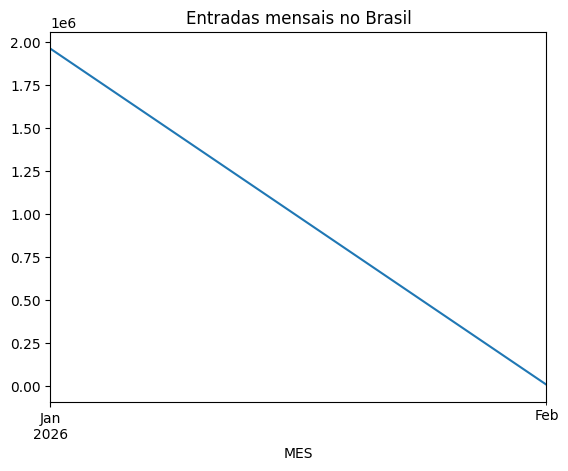

In [16]:
df_mes = df_sismigra_total.groupby('MES')['QTD_DIF'].sum()

df_mes.plot(kind='line')
plt.title('Entradas mensais no Brasil')
plt.show()

In [17]:
df_mes = df_sismigra_total.groupby('MES')['QTD_DIF'].sum().reset_index()
display(df_mes)

,MES,QTD_DIF
0,2026-01,1958579.00
1,2026-02,7179.00


In [18]:
df_uf = (
    df_sismigra_total
    .groupby('UF')['QTD_DIF']
    .sum()
    .reset_index()
)
df_uf = df_uf.sort_values(by='QTD_DIF', ascending=False)
display(df_uf.head(5))


,UF,QTD_DIF
27,SP,675395.00
19,PR,217396.00
25,SC,210601.00
20,RJ,170714.00
24,RS,158981.00


In [19]:
df_uf_nac = (
    df_sismigra_total
    .groupby(['UF', 'NACIONALIDADE','CLASSIFICACAO','TIPO_MOVIMENTO'])['QTD_DIF']
    .sum()
    .reset_index()
)
display(df_uf_nac.sort_values(by='UF', ascending=False))

,UF,NACIONALIDADE,CLASSIFICACAO,TIPO_MOVIMENTO,QTD_DIF
11598,TO,VENEZUELA,Temporário,RETRAÇÃO,-1.00
11447,TO,CUBA,Temporário,ESTÁVEL,0.00
11458,TO,EQUADOR,Temporário,CRESCIMENTO,4.00
11457,TO,EQUADOR,Residente,ESTÁVEL,0.00
11456,TO,EQUADOR,Residente,CRESCIMENTO,5.00
...,...,...,...,...,...
49,--,PAÍSES BAIXOS,Residente,ESTÁVEL,0.00
50,--,PERU,Residente,CRESCIMENTO,9.00
51,--,PERU,Residente,ESTÁVEL,0.00
52,--,PORTUGAL,Residente,CRESCIMENTO,21.00


In [20]:
df_es = df_sismigra_total.loc[df_sismigra_total['UF'] == 'ES'].sort_values(
    by='QTD_DIF', ascending=False
    )
display(df_es)

,UF,NACIONALIDADE,CLASSIFICACAO,QTD,MES,QTD_DIF,TIPO_MOVIMENTO
3626,ES,VENEZUELA,Residente,1238,2026-01,1238.00,CRESCIMENTO
3624,ES,PORTUGAL,Residente,1162,2026-01,1162.00,CRESCIMENTO
3622,ES,VENEZUELA,Temporário,919,2026-01,919.00,CRESCIMENTO
3636,ES,ITÁLIA,Residente,762,2026-01,762.00,CRESCIMENTO
3629,ES,COLÔMBIA,Residente,702,2026-01,702.00,CRESCIMENTO
...,...,...,...,...,...,...,...
10888,ES,EQUADOR,Temporário,16,2026-02,-2.00,RETRAÇÃO
10868,ES,CHINA,Residente,320,2026-02,-2.00,RETRAÇÃO
11010,ES,GANA,Temporário,4,2026-02,-3.00,RETRAÇÃO
11061,ES,NIGÉRIA,Temporário,3,2026-02,-3.00,RETRAÇÃO


In [21]:
df_uf = (
    df_sismigra_total
    .groupby('UF', as_index=False)
    .agg({
        'QTD_DIF': 'sum',
        'QTD': 'sum',
        'NACIONALIDADE': 'nunique'
    })
)
display(df_uf.sort_values(by='QTD_DIF', ascending=False).head(5))

,UF,QTD_DIF,QTD,NACIONALIDADE
27,SP,675395.00,1349538,212
19,PR,217396.00,432750,170
25,SC,210601.00,418816,160
20,RJ,170714.00,342221,187
24,RS,158981.00,317827,158


In [22]:
df_uf_map = (
    df_sismigra_total
    .groupby('UF')['QTD_DIF']
    .sum()
    .reset_index()
)
display(df_uf_map.sort_values(by='QTD_DIF', ascending=False).head(5))

,UF,QTD_DIF
27,SP,675395.00
19,PR,217396.00
25,SC,210601.00
20,RJ,170714.00
24,RS,158981.00


In [23]:
import requests
import json

url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

response = requests.get(url)
geojson = response.json()

# salvar arquivo
with open('brazil-states.geojson', 'w', encoding='utf-8') as f:
    json.dump(geojson, f, ensure_ascii=False)

print("GeoJSON salvo com sucesso!")
fig = px.choropleth(
    df_uf,
    geojson=geojson,
    locations='UF',
    featureidkey='properties.sigla',  # chave correta
    color='QTD_DIF',
    color_continuous_scale='Blues'
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.show()

SSLError: HTTPSConnectionPool(host='raw.githubusercontent.com', port=443): Max retries exceeded with url: /codeforamerica/click_that_hood/master/public/data/brazil-states.geojson (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1010)')))

In [ ]:
print(type(df_sismigra_total))
print(df_sismigra_total.head())

<class 'pandas.core.frame.DataFrame'>
   UF NACIONALIDADE CLASSIFICACAO     QTD      MES   QTD_DIF TIPO_MOVIMENTO
0  SP       BOLÍVIA     Residente  106567  2026-01 106567.00    CRESCIMENTO
1  SP         INDIA     Residente    1445  2026-01   1445.00    CRESCIMENTO
2  SP        ANGOLA    Temporário    8219  2026-01   8219.00    CRESCIMENTO
3  SP         CHILE     Residente   15612  2026-01  15612.00    CRESCIMENTO
4  SP         JAPÃO     Residente   36258  2026-01  36258.00    CRESCIMENTO
